In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import numpy as np


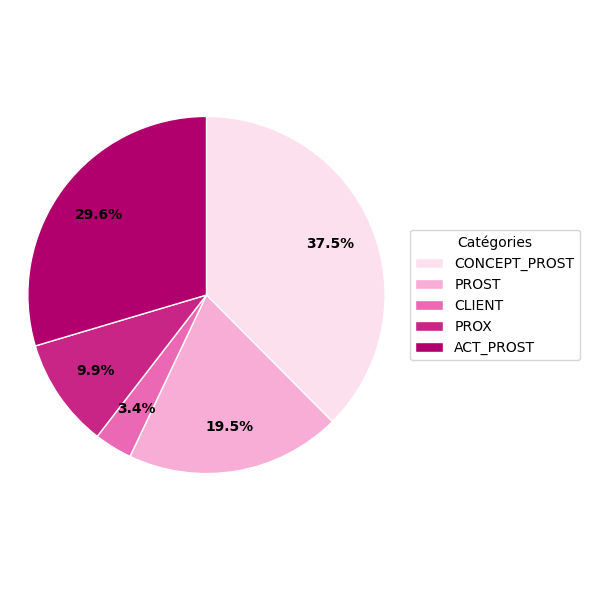

In [ ]:
import csv
from collections import Counter
import matplotlib.pyplot as plt

# 1. Charger le CSV et compter les occurrences de la colonne 'type'
counts = Counter()

with open('Corpus/ngrams/ngrams_NER_enrichi.csv', newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        typ = row.get('type', 'inconnu')
        counts[typ] += 1

# 2. Préparer les données pour le camembert
labels = list(counts.keys())
sizes = list(counts.values())
n = len(labels)
total = sum(sizes)


# Générer n couleurs équidistantes à partir de la colormap 'rose'
colors = [rose(0.11 + (i / (n - 1))) if n > 1 else rose(0.5) for i in range(n)]

# 4. Tracer le camembert sans labels directement sur les parts
fig, ax = plt.subplots(figsize=(6, 6))
wedges, _ = ax.pie(
    sizes,
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1)
)
ax.axis('equal')

for i, wedge in enumerate(wedges):
    angle = np.deg2rad((wedge.theta2 + wedge.theta1) / 2.0)
    r = 0.65  # distance au centre
    x = r * np.cos(angle)
    y = r * np.sin(angle)
    pct = sizes[i] / total * 100
    ax.text(
        x, y,
        f"{pct:.1f}%",
        ha='center', va='center',
        color='black', fontsize=10, fontweight='bold'
    )

# 5. Ajouter une légende sur le côté avec couleurs + labels
ax.legend(
    wedges,
    labels,
    title="Catégories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)  # à droite du graphique
)

plt.tight_layout()
plt.savefig('img/camembert_types_legende.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
labels

['CONCEPT_PROST', 'PROST', 'CLIENT', 'PROX', 'ACT_PROST', 'CONCEPT_PROX']

/tmp/ipykernel_650765/4224434262.py:5: UserWarning: Overwriting the cmap 'rose' that was already in the registry.
  mpl.colormaps.register(rose, name="rose", force=True)


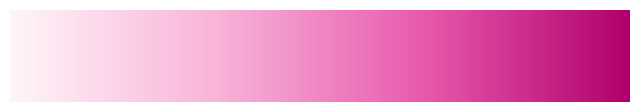

In [11]:
rose = LinearSegmentedColormap.from_list(
    "rose",
    ["#fff5f9", "#f8b4d9", "#e85aad", "#b1006d"]
)
mpl.colormaps.register(rose, name="rose", force=True)

# exemple d'affichage
gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1.2))
plt.imshow(gradient, aspect="auto", cmap=rose)
plt.axis("off")
plt.show()

In [32]:
import polars as pl

In [33]:
df = pl.scan_parquet('Corpus/corpus_complet.parquet').select(['texte']).collect()

In [35]:
stats = (
    df
    .select(
        pl.col("texte")
        .fill_null("")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .str.split(" ")
        .list.len()
        .alias("nombre_mots")
    )
    .select(
        pl.col("nombre_mots").min().alias("min_mots"),
        pl.col("nombre_mots").max().alias("max_mots"),
        pl.col("nombre_mots").mean().alias("moyenne_mots"),
        pl.col("nombre_mots").median().alias("mediane_mots"),
    )
)

print(stats)

shape: (1, 4)
┌──────────┬──────────┬──────────────┬──────────────┐
│ min_mots ┆ max_mots ┆ moyenne_mots ┆ mediane_mots │
│ ---      ┆ ---      ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ f64          ┆ f64          │
╞══════════╪══════════╪══════════════╪══════════════╡
│ 1        ┆ 142570   ┆ 632.915471   ┆ 462.0        │
└──────────┴──────────┴──────────────┴──────────────┘


In [38]:
df_avec_longueur = (
    df
    .with_columns(
        pl.col("texte")
        .fill_null("")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .str.split(" ")
        .list.len()
        .alias("nombre_mots")
    )
)

print(
    df_avec_longueur
    .sort("nombre_mots")
    .select("nombre_mots", "texte")
    .head(5) # à enlever si df est un DataFrame
)

print(
    df_avec_longueur
    .sort("nombre_mots", descending=True)
    .select("nombre_mots", "texte")
    .head(5)
)


shape: (5, 2)
┌─────────────┬───────────────────────────────┐
│ nombre_mots ┆ texte                         │
│ ---         ┆ ---                           │
│ u32         ┆ str                           │
╞═════════════╪═══════════════════════════════╡
│ 1           ┆ Policiers                     │
│ 1           ┆ Littérature                   │
│ 1           ┆ Essais                        │
│ 2           ┆  France  []                   │
│ 2           ┆ NonRedactionnel Prostitution  │
└─────────────┴───────────────────────────────┘
shape: (5, 2)
┌─────────────┬─────────────────────────────────┐
│ nombre_mots ┆ texte                           │
│ ---         ┆ ---                             │
│ u32         ┆ str                             │
╞═════════════╪═════════════════════════════════╡
│ 142570      ┆ Les tendances mode printemps 2… │
│ 69273       ┆ Prenez rendez-vous avec votre … │
│ 68454       ┆ Pour vos retailles de cèdre, p… │
│ 28119       ┆ Cinéma Brabant wallon BRAINE

In [43]:
import polars as pl

resultat = (
    df
    .select(
        pl.col("texte")
        .fill_null("")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .str.split(" ")
        .list.len()
        .alias("nombre_mots")
    )
    .select(
        (pl.col("nombre_mots") < 5).sum().alias("moins_de_5_mots"),
        (pl.col("nombre_mots") < 10).sum().alias("moins_de_10_mots"),
        (pl.col("nombre_mots") < 20).sum().alias("moins_de_20_mots"),
    )
)

print(resultat)

shape: (1, 3)
┌─────────────────┬──────────────────┬──────────────────┐
│ moins_de_5_mots ┆ moins_de_10_mots ┆ moins_de_20_mots │
│ ---             ┆ ---              ┆ ---              │
│ u32             ┆ u32              ┆ u32              │
╞═════════════════╪══════════════════╪══════════════════╡
│ 17              ┆ 137              ┆ 685              │
└─────────────────┴──────────────────┴──────────────────┘


In [67]:
import polars as pl
import matplotlib.pyplot as plt

df_mots = (
    df
    .select(
        pl.col("texte")
        .fill_null("")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .str.split(" ")
        .list.len()
        .alias("nombre_mots")
    )
)


In [81]:
limite_x = df_mots.select(
    pl.col("nombre_mots").quantile(0.95)
).item()

In [82]:
distribution = (
    df_mots
    .filter(pl.col("nombre_mots") <= limite_x)
    .group_by("nombre_mots")
    .len(name="nombre_articles")
    .sort("nombre_mots")
)


In [83]:
taille_fenetre = 101  # doit idéalement être impaire

distribution_lissee = (
    distribution
    .with_columns(
        pl.col("nombre_articles")
        .rolling_mean(
            window_size=taille_fenetre,
            center=True,
            min_samples=1
        )
        .alias("nombre_articles_lisse")
    )
)

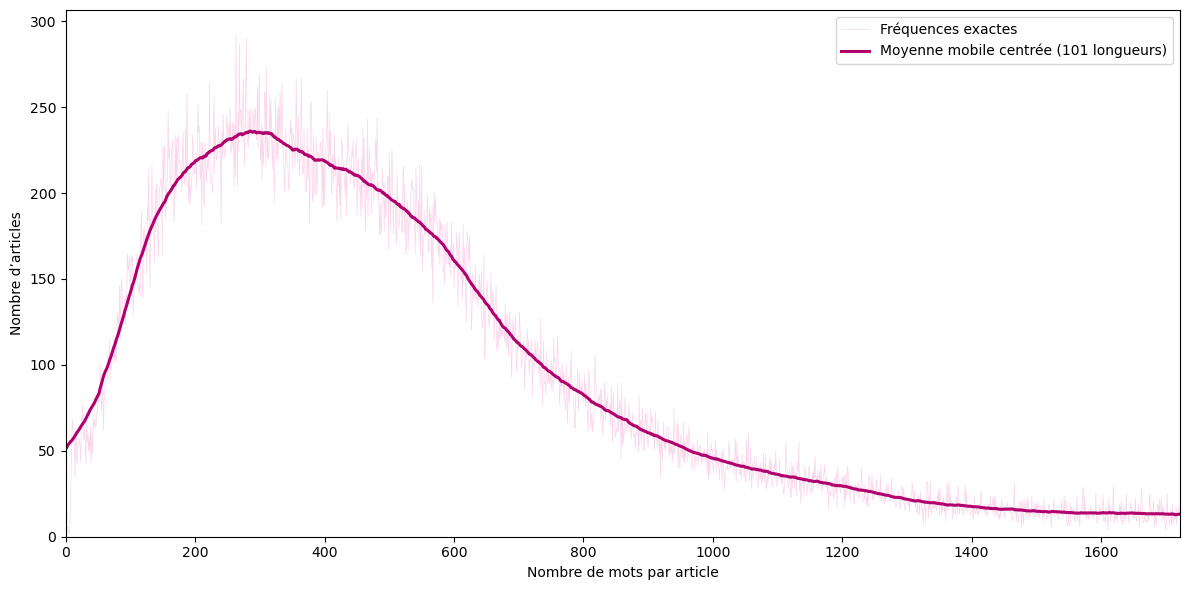

In [86]:
fig, ax = plt.subplots(figsize=(12, 6))

# Facultatif : la courbe brute, discrète en arrière-plan
ax.plot(
    distribution["nombre_mots"].to_numpy(),
    distribution["nombre_articles"].to_numpy(),
    color="#E85AAD",
    linewidth=0.5,
    alpha=0.25,
    label="Fréquences exactes"
)

# Courbe lissée
ax.plot(
    distribution_lissee["nombre_mots"].to_numpy(),
    distribution_lissee["nombre_articles_lisse"].to_numpy(),
    color="#B1006D",
    linewidth=2.2,
    label=f"Moyenne mobile centrée ({taille_fenetre} longueurs)"
)

ax.set_xlim(0, limite_x)
ax.set_ylim(0)
ax.set_xlabel("Nombre de mots par article")
ax.set_ylabel("Nombre d’articles")
ax.legend()

plt.tight_layout()
plt.savefig('img/distribution_mot_article.png', dpi=300, bbox_inches='tight')
plt.show()

ColumnNotFoundError: "milieu_tranche" not found

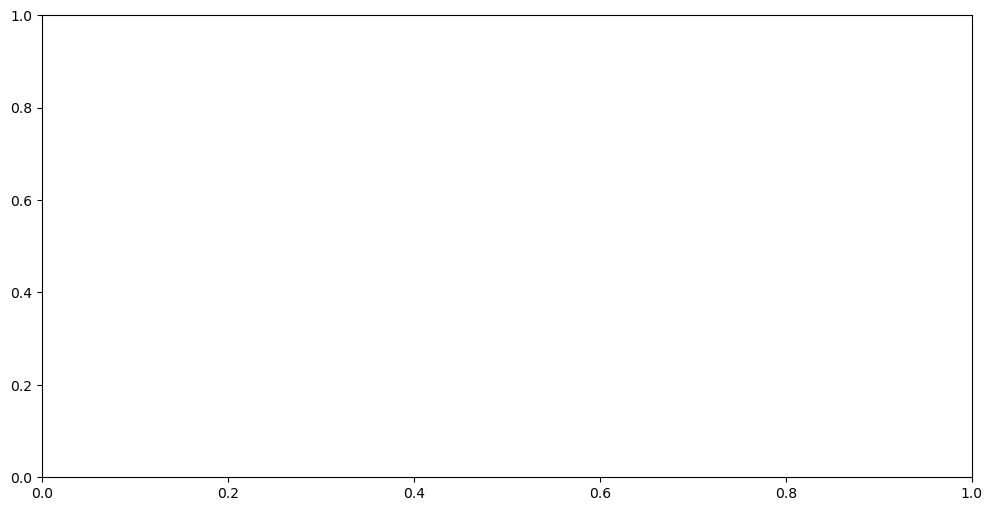

In [69]:
distribution_lissee = distribution.with_columns(
    pl.col("nombre_articles")
    .rolling_mean(window_size=5, center=True)
    .alias("articles_lisses")
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    distribution_lissee["milieu_tranche"].to_numpy(),
    distribution_lissee["articles_lisses"].to_numpy(),
    color="#C44E52",
    linewidth=2.2,
    label="Moyenne mobile sur 5 tranches"
)

ax.set_xlim(0, limite_x)
ax.set_xlabel("Nombre de mots par article")
ax.set_ylabel("Nombre d’articles par tranche")
ax.set_title("Distribution lissée de la longueur des articles")
ax.legend()

plt.tight_layout()
plt.show()

In [3]:
locale.setlocale(locale.LC_TIME, "fr_FR.UTF-8")

'fr_FR.UTF-8'

In [5]:
import os
import json
import datetime
import locale
import pandas as pd
import polars as pl

In [4]:
source_folder = "json_output_embed"

pays = []
sujets = []
pertinences = []
dates = []
journaux = []

for root, dirs, files in os.walk(source_folder):
    json_files = [f for f in files if f.endswith(".json")]
    
    if not json_files:
        continue

    for filename in json_files:
        src_path = os.path.join(root, filename)
        with open(src_path, "r") as f:
            file = json.load(f)

        if file['texte'] == "":
            continue

        if not file.get("pays"):
            pays.append("inconnu")
        else :
            pays.append(file['pays'])
        sujets.append(file['type'])
        pertinences.append(file['pertinence'])
        date_list = [datetime.datetime.strptime(date, "%d %B %Y").date() for date in file['dates']]
        dates.append(date_list)

        if not file.get("journaux"):
            journaux.append(["inconnu"])
        else :
            journaux.append(file['journaux'])



KeyboardInterrupt: 

In [5]:
df = pd.DataFrame({
    "pays": pays,
    "sujets": sujets,
    "pertinences": pertinences,
    "dates": dates,
    "journaux": journaux
})

In [7]:
lf = pl.scan_parquet("corpus/corpus_complet.parquet")
lf.schema

/tmp/ipykernel_456789/604096312.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  lf.schema


Schema([('id', String),
        ('texte', String),
        ('journaux', List(String)),
        ('dates', List(String)),
        ('pays', List(String)),
        ('embedding', List(Float64)),
        ('type', String),
        ('pertinence', List(String)),
        ('entities', List(Struct({'text': String, 'label': String}))),
        ('entities_org', List(String)),
        ('entities_places', List(String)),
        ('tokens', List(String)),
        ('lemmas', List(String)),
        ('upos', List(String)),
        ('feats', List(String)),
        ('bigrams_noun_adj', List(String)),
        ('trigrams_noun_adj', List(String)),
        ('trigrams_with_verbs', List(String))])

In [8]:
colonnes = ['id', 'journaux', 'dates', 'pays', 'type']

In [9]:
df = lf.select(colonnes).collect()

In [11]:
df.head()

id,journaux,dates,pays,type
str,list[str],list[str],list[str],str
"""583dcb91673c661e179b5235c7998d…","[""Le Progrès - Lyon""]","[""4 mars 2005""]","[""France""]","""Réalité"""
"""a92817744d9108efb889a74e4a0104…","[""Le Soir""]","[""20 janvier 2010""]","[""Belgique""]","""Fiction"""
"""e38611f965034aa72c0223810decbf…","[""Nord Éclair"", ""La Voix du Nord""]","[""2 février 2021"", ""2 février 2021""]","[""France""]","""Réalité"""
"""6877eee607c788cfb47fdf16a7992f…","[""La Dépêche du Midi"", ""Libération (site web)""]","[""4 avril 2018"", ""3 avril 2018""]","[""France""]","""Fiction"""
"""dee3e67e182ba3209f24dfd10e3697…","[""La Tribune dimanche (France)"", ""La Tribune (France) (site web)""]","[""29 décembre 2024"", ""1 décembre 2024""]","[""France""]","""Fiction"""


In [ ]:
count = {}
for pays in df['pays']:
    if pays == "inconnu":
        count["inconnu"] = count.get("inconnu", 0) + 1
        continue
    for pay in pays:
        count[pay] = count.get(pay, 0) + 1


In [37]:
unk = (count['inconnu'] + count['bimensuel'] + count['Presse'] + count['trimestriel']) / len(df['pays'])

In [43]:
count["inconnu"] = unk * len(df['pays'])

In [44]:
del count['bimensuel']
del count['Presse']
del count['trimestriel']

KeyError: 'bimensuel'

In [49]:
sorted_info = sorted(count.items(), key=lambda x: x[1], reverse=True)

In [51]:
sorted_dict = {tuple[0]: tuple[1] / len(df['pays']) * 100 for tuple in sorted_info}

In [52]:
sorted_dict

{'France': 74.58444668077871,
 'Canada': 15.186637517206277,
 'Belgique': 7.763357277532938,
 'Suisse': 4.04506599113949,
 'Algérie': 2.089044661137523,
 'inconnu': 1.1202877930851003,
 'Chine': 0.3736220517981284,
 'Burkina': 0.05031752090779748,
 'Maroc': 0.04916079628922742,
 'Côte': 0.041642086268522054,
 'Liban': 0.03412337624781669,
 'Tunisie': 0.02718302853639634,
 'Sénégal': 0.024291216989971196,
 'Tchad': 0.01850759389712091,
 'Burundi': 0.016194144659980796,
 'Cameroun': 0.0005783623092850285,
 'Royaume-UniGrand': 0.0005783623092850285,
 'Turquie': 0.0005783623092850285,
 'Guinée': 0.0005783623092850285,
 'Mauritanie': 0.0005783623092850285,
 'Togo': 0.0005783623092850285,
 'Mali': 0.0005783623092850285}

In [1]:
import polars as pl

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [3]:
COLONNES = [
    'id',
    'journaux',
    'dates',
    'pays',
    'type',
    'entities_places',
    'bigrams_noun_adj',
    'trigrams_noun_adj',
    'trigrams_with_verbs'
]

In [4]:

lf = (
    pl.scan_parquet(
        "corpus/corpus_complet.parquet",
        low_memory=True,   # réduit la pression mémoire (au prix d'un peu de perf)
        rechunk=False,     # évite de recopier les chunks en mémoire contiguë
    )
    .select(COLONNES)     # projection pushdown : seules ces colonnes sont lues du disque
)

In [5]:
df = lf.collect()  # exécution du plan de requête et chargement en mémoire

In [14]:
df.schema

Schema([('id', String),
        ('journaux', List(String)),
        ('dates', List(String)),
        ('pays', List(String)),
        ('type', String),
        ('entities_places', List(String)),
        ('bigrams_noun_adj', List(String)),
        ('trigrams_noun_adj', List(String)),
        ('trigrams_with_verbs', List(String))])

In [16]:
print("Types :", df["type"].unique().to_list())

Types : ['Fiction', 'Réalité']


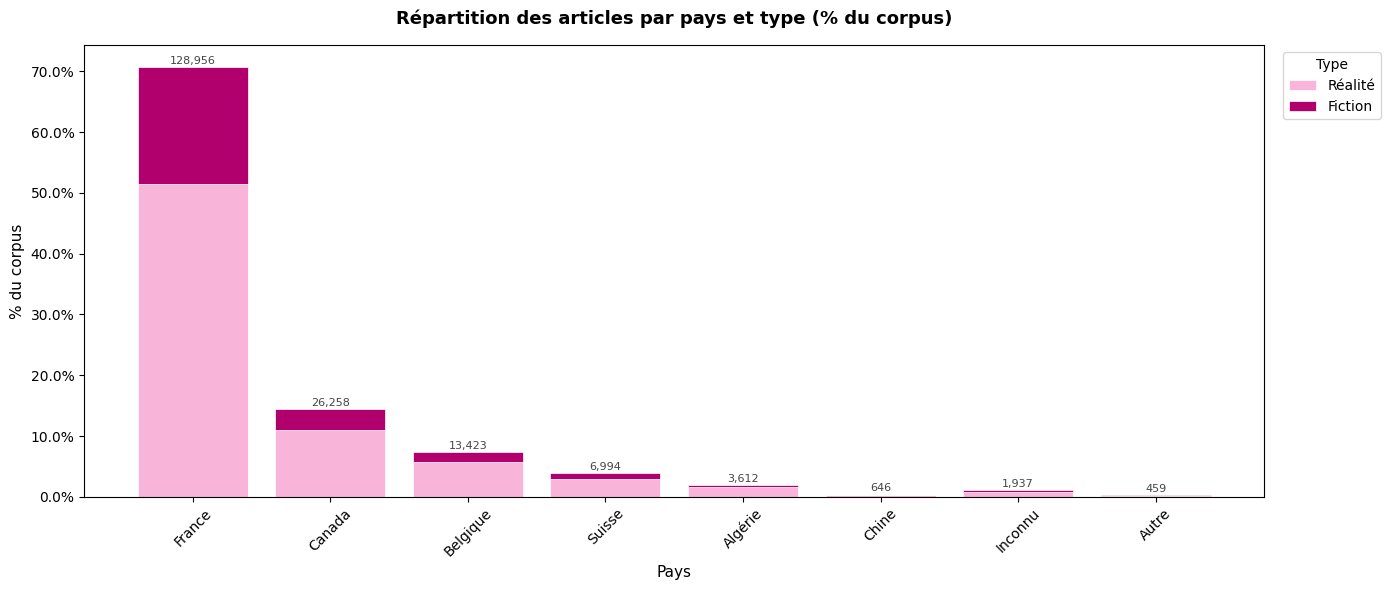

In [33]:
# ── Mappings
REMPLACE_INCONNU = {'bimensuel', 'Presse', 'trimestriel'}
REMPLACE_AUTRE   = {
    'Burkina', 'Maroc', 'Côte', 'Liban', 'Tunisie', 'Sénégal',
    'Tchad', 'Burundi', 'Cameroun', 'Royaume-UniGrand', 'Turquie',
    'Guinée', 'Mauritanie', 'Togo', 'Mali'
}

# ── Explode : une ligne par (article × pays)
df_exp = (
    df
    .explode("pays")
    .with_columns(
        pl.when(pl.col("pays").is_null() | pl.col("pays").is_in(list(REMPLACE_INCONNU)))
          .then(pl.lit("Inconnu"))
          .when(pl.col("pays").is_in(list(REMPLACE_AUTRE)))
          .then(pl.lit("Autre"))
          .otherwise(pl.col("pays"))
          .alias("pays_norm")
    )
)

# ── Compter les (id, pays_norm, type) distincts pour éviter doublons
#    si un article a plusieurs fois le même pays dans sa liste
counts = (
    df_exp
    .unique(subset=["id", "pays_norm", "type"])
    .group_by(["pays_norm", "type"])
    .agg(pl.len().alias("n"))
)

# ── Pivoter
pivot = counts.pivot(on="type", index="pays_norm", values="n").fill_null(0)
types = [c for c in pivot.columns if c != "pays_norm"]

# ── Trier par total desc, Autre + Inconnu à la fin
pivot = pivot.with_columns(
    pl.sum_horizontal([pl.col(t) for t in types]).alias("total")
).sort("total", descending=True)

main    = pivot.filter(~pl.col("pays_norm").is_in(["Autre", "Inconnu"]))
special = pivot.filter( pl.col("pays_norm").is_in(["Autre", "Inconnu"]))
pivot_sorted = pl.concat([main, special])

pays_labels = pivot_sorted["pays_norm"].to_list()
vals = {t: pivot_sorted[t].to_list() for t in types}


# ── Normalisation en pourcentage du corpus total
total_corpus = sum(pivot_sorted["total"].to_list())

vals_pct = {t: (pivot_sorted[t] / total_corpus * 100).to_list() for t in types}

# ── Graphique barres empilées en %
colors = ["#f8b4d9", "#b1006d"]

fig, ax = plt.subplots(figsize=(14, 6))
bottoms = np.zeros(len(pays_labels))

for i, t in enumerate(types):
    v = np.array(vals_pct[t])
    ax.bar(pays_labels, v, bottom=bottoms, color=colors[i],
           label=t, edgecolor="white", linewidth=0.5)
    bottoms += v

# ── Annoter le total brut au-dessus de chaque barre
totaux = pivot_sorted["total"].to_list()
for j, (total, top) in enumerate(zip(totaux, bottoms)):
    ax.text(j, top + 0.2, f"{total:,}", ha="center", va="bottom",
            fontsize=8, color="#444444")

ax.set_title("Répartition des articles par pays et type (% du corpus)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Pays", fontsize=11)
ax.set_ylabel("% du corpus", fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

plt.tight_layout()
plt.savefig("articles_par_pays_type_pct.png", dpi=150, bbox_inches="tight")
plt.show()

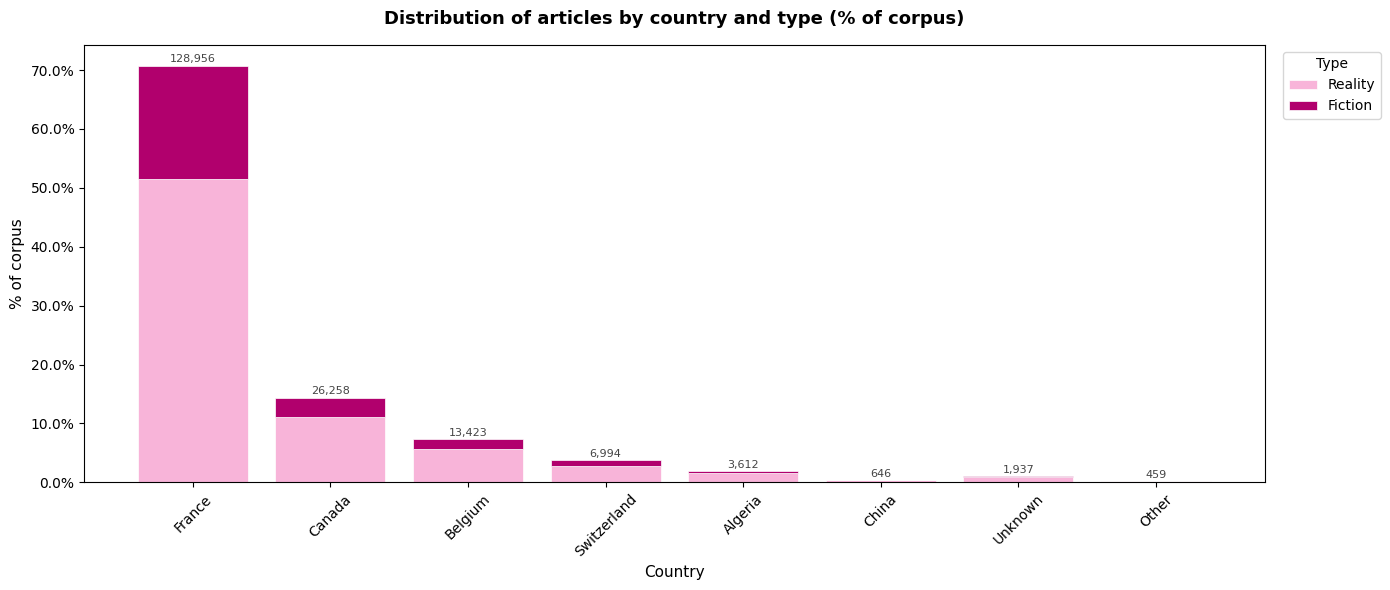

In [10]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# ── Mappings
REMPLACE_INCONNU = {'bimensuel', 'Presse', 'trimestriel'}
REMPLACE_AUTRE   = {
    'Burkina', 'Maroc', 'Côte', 'Liban', 'Tunisie', 'Sénégal',
    'Tchad', 'Burundi', 'Cameroun', 'Royaume-UniGrand', 'Turquie',
    'Guinée', 'Mauritanie', 'Togo', 'Mali'
}

DICT_TRANSLATION = {
    "France": "France",
    "Belgique": "Belgium",
    "Algérie": "Algeria",
    "Chine": "China",
    "Suisse": "Switzerland",
    "Canada": "Canada"
}

# ── Explode
df_exp = (
    df
    .explode("pays")
    .with_columns(
        pl.when(pl.col("pays").is_null() | pl.col("pays").is_in(list(REMPLACE_INCONNU)))
          .then(pl.lit("Unknown"))
          .when(pl.col("pays").is_in(list(REMPLACE_AUTRE)))
          .then(pl.lit("Other"))
          .otherwise(
              pl.col("pays").map_elements(
                  lambda x: DICT_TRANSLATION.get(x, x),
                  return_dtype=pl.Utf8
              )
          )
          .alias("pays_norm")
    )
)

TYPE_TRANSLATION = {
    "Réalité": "Reality",
    "Fiction": "Fiction"
}

counts = (
    df_exp
    .unique(subset=["id", "pays_norm", "type"])
    .with_columns(
        pl.col("type").map_elements(
            lambda x: TYPE_TRANSLATION.get(x, x),
            return_dtype=pl.Utf8
        ).alias("type")
    )
    .group_by(["pays_norm", "type"])
    .agg(pl.len().alias("n"))
)

# ── Pivot
pivot = counts.pivot(on="type", index="pays_norm", values="n").fill_null(0)
types = [c for c in pivot.columns if c != "pays_norm"]

# ── Sort by total desc, Other + Unknown at the end
pivot = pivot.with_columns(
    pl.sum_horizontal([pl.col(t) for t in types]).alias("total")
).sort("total", descending=True)

main    = pivot.filter(~pl.col("pays_norm").is_in(["Other", "Unknown"]))
special = pivot.filter( pl.col("pays_norm").is_in(["Other", "Unknown"]))
pivot_sorted = pl.concat([main, special])

pays_labels = pivot_sorted["pays_norm"].to_list()

# ── Percentage normalisation
total_corpus = pivot_sorted["total"].sum()

vals_pct = {
    t: (pivot_sorted[t].cast(pl.Float64) / total_corpus * 100).to_list()
    for t in types
}

# ── Chart
colors = ["#f8b4d9", "#b1006d"]

fig, ax = plt.subplots(figsize=(14, 6))
bottoms = np.zeros(len(pays_labels))

for i, t in enumerate(types):
    v = np.array(vals_pct[t])
    ax.bar(pays_labels, v, bottom=bottoms, color=colors[i],
           label=t, edgecolor="white", linewidth=0.5)
    bottoms += v

totaux = pivot_sorted["total"].to_list()
for j, (total, top) in enumerate(zip(totaux, bottoms)):
    ax.text(j, top + 0.2, f"{total:,}", ha="center", va="bottom",
            fontsize=8, color="#444444")

ax.set_title("Distribution of articles by country and type (% of corpus)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Country", fontsize=11)
ax.set_ylabel("% of corpus", fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

plt.tight_layout()
plt.savefig("articles_by_country_type_pct.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# ── Pivoter et calculer le % fiction
tableau = (
    counts
    .pivot(on="type", index="pays_norm", values="n")
    .fill_null(0)
)

types = [c for c in tableau.columns if c != "pays_norm"]

tableau = tableau.with_columns(
    pl.sum_horizontal([pl.col(t) for t in types]).alias("total")
)

# Adapte "fiction" par le nom exact du type dans tes données
tableau = tableau.with_columns(
    (pl.col("Fiction") / pl.col("total") * 100).round(1).alias("% Fiction")
)

# Trier par % fiction décroissant, Autre + Inconnu à la fin
main    = tableau.filter(~pl.col("pays_norm").is_in(["Autre", "Inconnu"]))
special = tableau.filter( pl.col("pays_norm").is_in(["Autre", "Inconnu"]))
tableau_final = (
    pl.concat([main.sort("% Fiction", descending=True), special])
    .select(["pays_norm", "Fiction", *[t for t in types if t != "Fiction"], "total", "% Fiction"])
    .rename({"pays_norm": "Pays", "total": "Total", "Fiction": "Fiction"})
)

print(tableau_final)

shape: (8, 5)
┌──────────┬─────────┬─────────┬────────┬───────────┐
│ Pays     ┆ Fiction ┆ Réalité ┆ Total  ┆ % Fiction │
│ ---      ┆ ---     ┆ ---     ┆ ---    ┆ ---       │
│ str      ┆ u32     ┆ u32     ┆ u32    ┆ f64       │
╞══════════╪═════════╪═════════╪════════╪═══════════╡
│ France   ┆ 35216   ┆ 93740   ┆ 128956 ┆ 27.3      │
│ Suisse   ┆ 1789    ┆ 5205    ┆ 6994   ┆ 25.6      │
│ Canada   ┆ 6084    ┆ 20174   ┆ 26258  ┆ 23.2      │
│ Belgique ┆ 2975    ┆ 10448   ┆ 13423  ┆ 22.2      │
│ Algérie  ┆ 650     ┆ 2962    ┆ 3612   ┆ 18.0      │
│ Chine    ┆ 7       ┆ 639     ┆ 646    ┆ 1.1       │
│ Autre    ┆ 103     ┆ 356     ┆ 459    ┆ 22.4      │
│ Inconnu  ┆ 399     ┆ 1538    ┆ 1937   ┆ 20.6      │
└──────────┴─────────┴─────────┴────────┴───────────┘


In [35]:
# ── Identifier les lignes avec les 3 colonnes vides (liste vide ou null)
def is_empty_list(col):
    return (pl.col(col).is_null()) | (pl.col(col).list.len() == 0)

df_ng = df.with_columns(
    (is_empty_list("bigrams_noun_adj") &
     is_empty_list("trigrams_noun_adj") &
     is_empty_list("trigrams_with_verbs")).alias("all_empty")
)

# ── Total des lignes vides
total_vides = df_ng.filter(pl.col("all_empty")).height
total = df_ng.height
print(f"Lignes avec les 3 colonnes vides : {total_vides:,} / {total:,} ({total_vides/total*100:.1f}%)")

# ── Appliquer le même nettoyage pays que précédemment
df_ng = (
    df_ng
    # 1. Exploser en premier — pays passe de List(String) à String
    .explode("pays")
    # 2. Ensuite seulement le pl.when sur des valeurs scalaires
    .with_columns(
        pl.when(pl.col("pays").is_null() | pl.col("pays").is_in(list(REMPLACE_INCONNU)))
          .then(pl.lit("Inconnu"))
          .when(pl.col("pays").is_in(list(REMPLACE_AUTRE)))
          .then(pl.lit("Autre"))
          .otherwise(pl.col("pays"))
          .alias("pays_norm")
    )
    .unique(subset=["id", "pays_norm", "type", "all_empty"])
)

# ── Tableau : pour chaque (pays, type) → total articles, nb vides, % vides
tableau_vides = (
    df_ng
    .group_by(["pays_norm", "type"])
    .agg([
        pl.len().alias("total"),
        pl.col("all_empty").sum().alias("n_vides"),
    ])
    .with_columns(
        (pl.col("n_vides") / pl.col("total") * 100).round(1).alias("% vides")
    )
    .sort(["pays_norm", "type"])
)

# ── Pivoter pour un affichage lisible : une ligne par pays
tableau_pivot = (
    tableau_vides
    .pivot(on="type", index="pays_norm",
           values=["total", "n_vides", "% vides"])
    .fill_null(0)
)

print(tableau_pivot)

Lignes avec les 3 colonnes vides : 83,325 / 172,900 (48.2%)
shape: (8, 7)
┌───────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ pays_norm ┆ total_Fictio ┆ total_Réalit ┆ n_vides_Fict ┆ n_vides_Réa ┆ % vides_Fic ┆ % vides_Réa │
│ ---       ┆ n            ┆ é            ┆ ion          ┆ lité        ┆ tion        ┆ lité        │
│ str       ┆ ---          ┆ ---          ┆ ---          ┆ ---         ┆ ---         ┆ ---         │
│           ┆ u32          ┆ u32          ┆ u32          ┆ u32         ┆ f64         ┆ f64         │
╞═══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╡
│ Algérie   ┆ 650          ┆ 2962         ┆ 473          ┆ 1235        ┆ 72.8        ┆ 41.7        │
│ Autre     ┆ 103          ┆ 356          ┆ 64           ┆ 183         ┆ 62.1        ┆ 51.4        │
│ Belgique  ┆ 2975         ┆ 10448        ┆ 2065         ┆ 4454        ┆ 69.4        ┆ 42.6        │
│ Canada    ┆ 608

In [39]:
def top5_ngrams(df, colonne):
    return (
        df
        .select(["pays_norm", "type", colonne])
        .explode(colonne)
        .filter(pl.col(colonne).is_not_null() & (pl.col(colonne) != ""))
        .group_by(["pays_norm", "type", colonne])
        .agg(pl.len().alias("freq"))
        .sort(["pays_norm", "type", "freq"], descending=[False, False, True])
        .group_by(["pays_norm", "type"], maintain_order=True)
        .agg(
            pl.col(colonne).head(5).alias(colonne)  # liste ordonnée, index = rang
        )
    )

resultats = (
    top5_ngrams(df_ng, "bigrams_noun_adj")
    .join(top5_ngrams(df_ng, "trigrams_noun_adj"),  on=["pays_norm", "type"], how="left")
    .join(top5_ngrams(df_ng, "trigrams_with_verbs"), on=["pays_norm", "type"], how="left")
    .sort(["pays_norm", "type"])
)

print(resultats)

shape: (16, 5)
┌───────────┬─────────┬─────────────────────────┬─────────────────────────┬────────────────────────┐
│ pays_norm ┆ type    ┆ bigrams_noun_adj        ┆ trigrams_noun_adj       ┆ trigrams_with_verbs    │
│ ---       ┆ ---     ┆ ---                     ┆ ---                     ┆ ---                    │
│ str       ┆ str     ┆ list[str]               ┆ list[str]               ┆ list[str]              │
╞═══════════╪═════════╪═════════════════════════╪═════════════════════════╪════════════════════════╡
│ Algérie   ┆ Fiction ┆ ["jeune_prostituée",    ┆ ["vieux_métier_monde",  ┆ ["avoir_relation_prost │
│           ┆         ┆ "fille_jo…              ┆ "propri…                ┆ ituée", …              │
│ Algérie   ┆ Réalité ┆ ["prostitution_mineur", ┆ ["prostitution_mineur_a ┆ ["accuser_prostitution │
│           ┆         ┆ "résea…                 ┆ bus", "…                ┆ _mineur"…              │
│ Autre     ┆ Fiction ┆ ["maison_clos",         ┆ ["tueur_série_prostitué ┆ 

In [40]:
resultats_csv = resultats.with_columns([
    pl.col("bigrams_noun_adj").list.join(" | "),
    pl.col("trigrams_noun_adj").list.join(" | "),
    pl.col("trigrams_with_verbs").list.join(" | "),
])

resultats_csv.write_csv("predictions/top5_ngrams_par_pays_type.csv")

# Anatomie du corpus

In [13]:
df.head()

id,journaux,dates,pays,type
str,list[str],list[str],list[str],str
"""583dcb91673c661e179b5235c7998d…","[""Le Progrès - Lyon""]","[""4 mars 2005""]","[""France""]","""Réalité"""
"""a92817744d9108efb889a74e4a0104…","[""Le Soir""]","[""20 janvier 2010""]","[""Belgique""]","""Fiction"""
"""e38611f965034aa72c0223810decbf…","[""Nord Éclair"", ""La Voix du Nord""]","[""2 février 2021"", ""2 février 2021""]","[""France""]","""Réalité"""
"""6877eee607c788cfb47fdf16a7992f…","[""La Dépêche du Midi"", ""Libération (site web)""]","[""4 avril 2018"", ""3 avril 2018""]","[""France""]","""Fiction"""
"""dee3e67e182ba3209f24dfd10e3697…","[""La Tribune dimanche (France)"", ""La Tribune (France) (site web)""]","[""29 décembre 2024"", ""1 décembre 2024""]","[""France""]","""Fiction"""


In [14]:
import datetime

In [50]:
Counter(df['type'])

Counter({'Réalité': 127323, 'Fiction': 45577})

In [20]:
liste_année = []
for date in df['dates']:
    if len(date) > 0:
        date_obj = date[0]
        date_obj = datetime.datetime.strptime(date_obj, "%d %B %Y").date() if isinstance(date_obj, str) else date_obj
        year = date_obj.year if isinstance(date_obj, datetime.date) else None
        liste_année.append(year)
    else:
        liste_année.append(None)

In [34]:
df = df.with_columns(
    pl.Series("année", liste_année)
)

In [36]:
df_avant_2000 = df.filter(pl.col("année") < 2000)

In [41]:
for journal in df_avant_2000['journaux']:
    print(journal[0] if len(journal) > 0 else "inconnu")

Moustique
Je souhaite aussi recevoir les bons plans des partenaires du site
L'Avenir
Science et Vie - Guerres et Histoires
Je souhaite aussi recevoir les bons plans des partenaires du site
Le Vif/L'Express
Dimanche 5 mars à 10h. Espace Tête d'Or. 103, boulevard Stalingrad. 4 €. Keep Ultime Tél. 06.79.16.83.58.
Encadré(s) :
importante.
MEZZO 200 20.30 Suites pour un monde en souffrance - Tanja Tetzlaff Concert. Réalisé par Stéphan Aubé (2023).
Le samedi 9 août, au soir, une Ford jaune et blanche s'arrête devant le10055 Cielo Drive, une villa cossue de style normand située sur les hauteurs de Beverly Hills. Quatre personnes s'en extraient avant de pénétrer dans la maison construite par l'actrice Michèle Morgan.
Elles seront également utilisées sous réserve des options souscrites, à des fins de ciblage publicitaire.
Science et Vie - Guerres et Histoires
Ils jalonnent leurs parcours depuis des siècles, des millénaires mêmes. Témoins silencieux de l'histoire des femmes, les objets laissent 

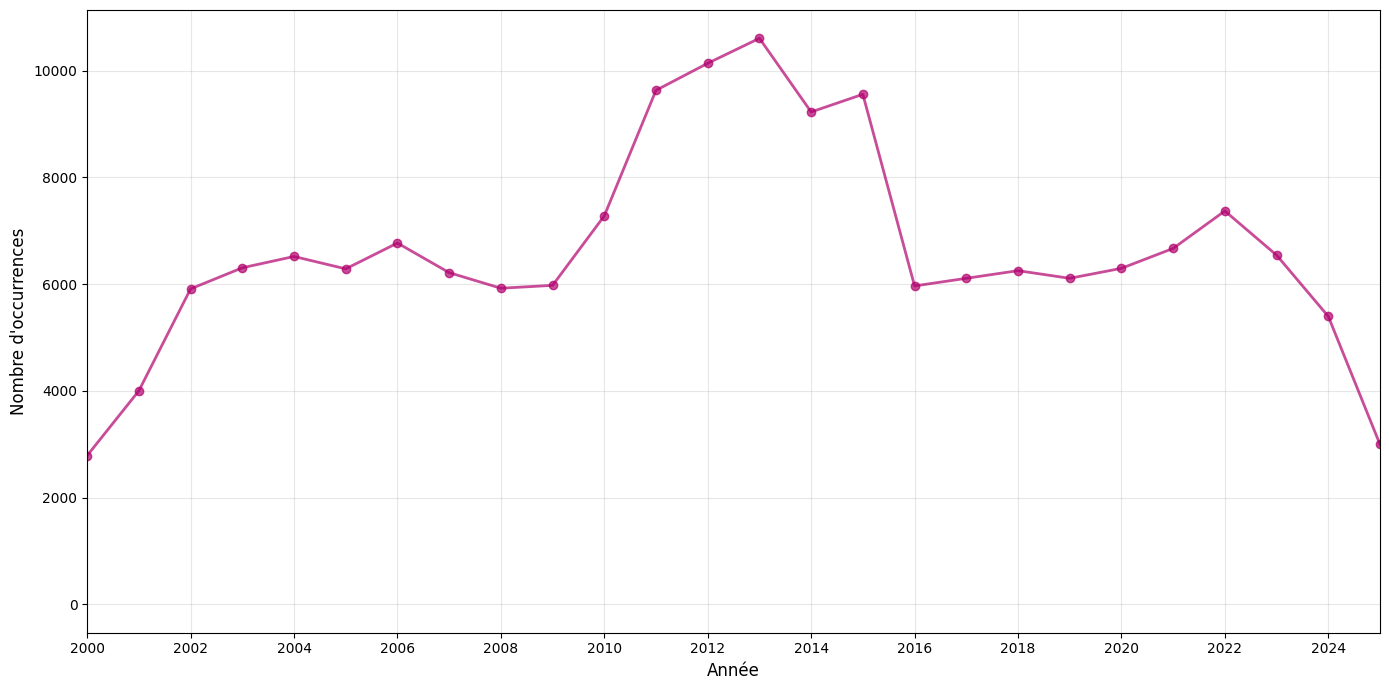

In [60]:
import matplotlib.pyplot as plt
from collections import Counter


# Remplace par ta vraie liste

# Compter les occurrences par année
annee_counts = Counter(liste_année)

# Trier par année
sorted_annees = sorted(annee_counts.keys())
counts = [annee_counts[a] for a in sorted_annees]

# Créer le graphique
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(sorted_annees, counts, linewidth=2, marker='o', markersize=6, alpha=0.7, color='#B1006D')

# Définir les limites de 2000 à 2025
ax.set_xlim(2000, 2025)

# Afficher les étiquettes tous les 2 ans
ax.set_xticks(range(2000, 2026, 2))

ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel("Nombre d'occurrences", fontsize=12)
#ax.set_title('Évolution temporelle (2000-2025)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolution_annees.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
année_canada = []
année_france = []
année_belgique = []
année_suisse = []
for pays, année in zip(df['pays'], df['année']):
    if len(pays) > 0:
        for p in pays:
            if p == "Canada":
                année_canada.append(année)
            elif p == "France":
                année_france.append(année)
            elif p == "Belgique":
                année_belgique.append(année)
            elif p == "Suisse":
                année_suisse.append(année)

[2014,
 2006,
 2008,
 2016,
 2000,
 2014,
 2015,
 2012,
 2011,
 2006,
 2010,
 2010,
 2013,
 2014,
 2009,
 2011,
 2011,
 2015,
 2007,
 2013,
 2011,
 2001,
 2006,
 2017,
 2009,
 2006,
 2007,
 2012,
 2011,
 2019,
 2020,
 2006,
 2015,
 2024,
 2018,
 2014,
 2013,
 2013,
 2001,
 2015,
 2011,
 2013,
 2011,
 2009,
 2011,
 2020,
 2011,
 2013,
 2003,
 2020,
 2008,
 2001,
 2013,
 2012,
 2011,
 2024,
 2019,
 2001,
 2010,
 2013,
 2007,
 2011,
 2002,
 2012,
 2010,
 2006,
 2012,
 2010,
 2006,
 2012,
 2008,
 2004,
 2025,
 2020,
 2017,
 2010,
 2009,
 2012,
 2010,
 2009,
 2010,
 2011,
 2015,
 2016,
 2013,
 2009,
 2015,
 2002,
 2022,
 2014,
 2014,
 2011,
 2020,
 2010,
 2010,
 2007,
 2016,
 2014,
 2018,
 2005,
 2011,
 2006,
 2003,
 2009,
 2006,
 2015,
 2014,
 2020,
 2011,
 2013,
 2021,
 2005,
 2003,
 2007,
 2017,
 2022,
 2023,
 2012,
 2013,
 2014,
 2009,
 2014,
 2023,
 2006,
 2015,
 2003,
 2005,
 2013,
 2014,
 2021,
 2025,
 2006,
 2008,
 2017,
 2011,
 2011,
 2006,
 2019,
 2012,
 2011,
 2014,
 2017,
 2022,

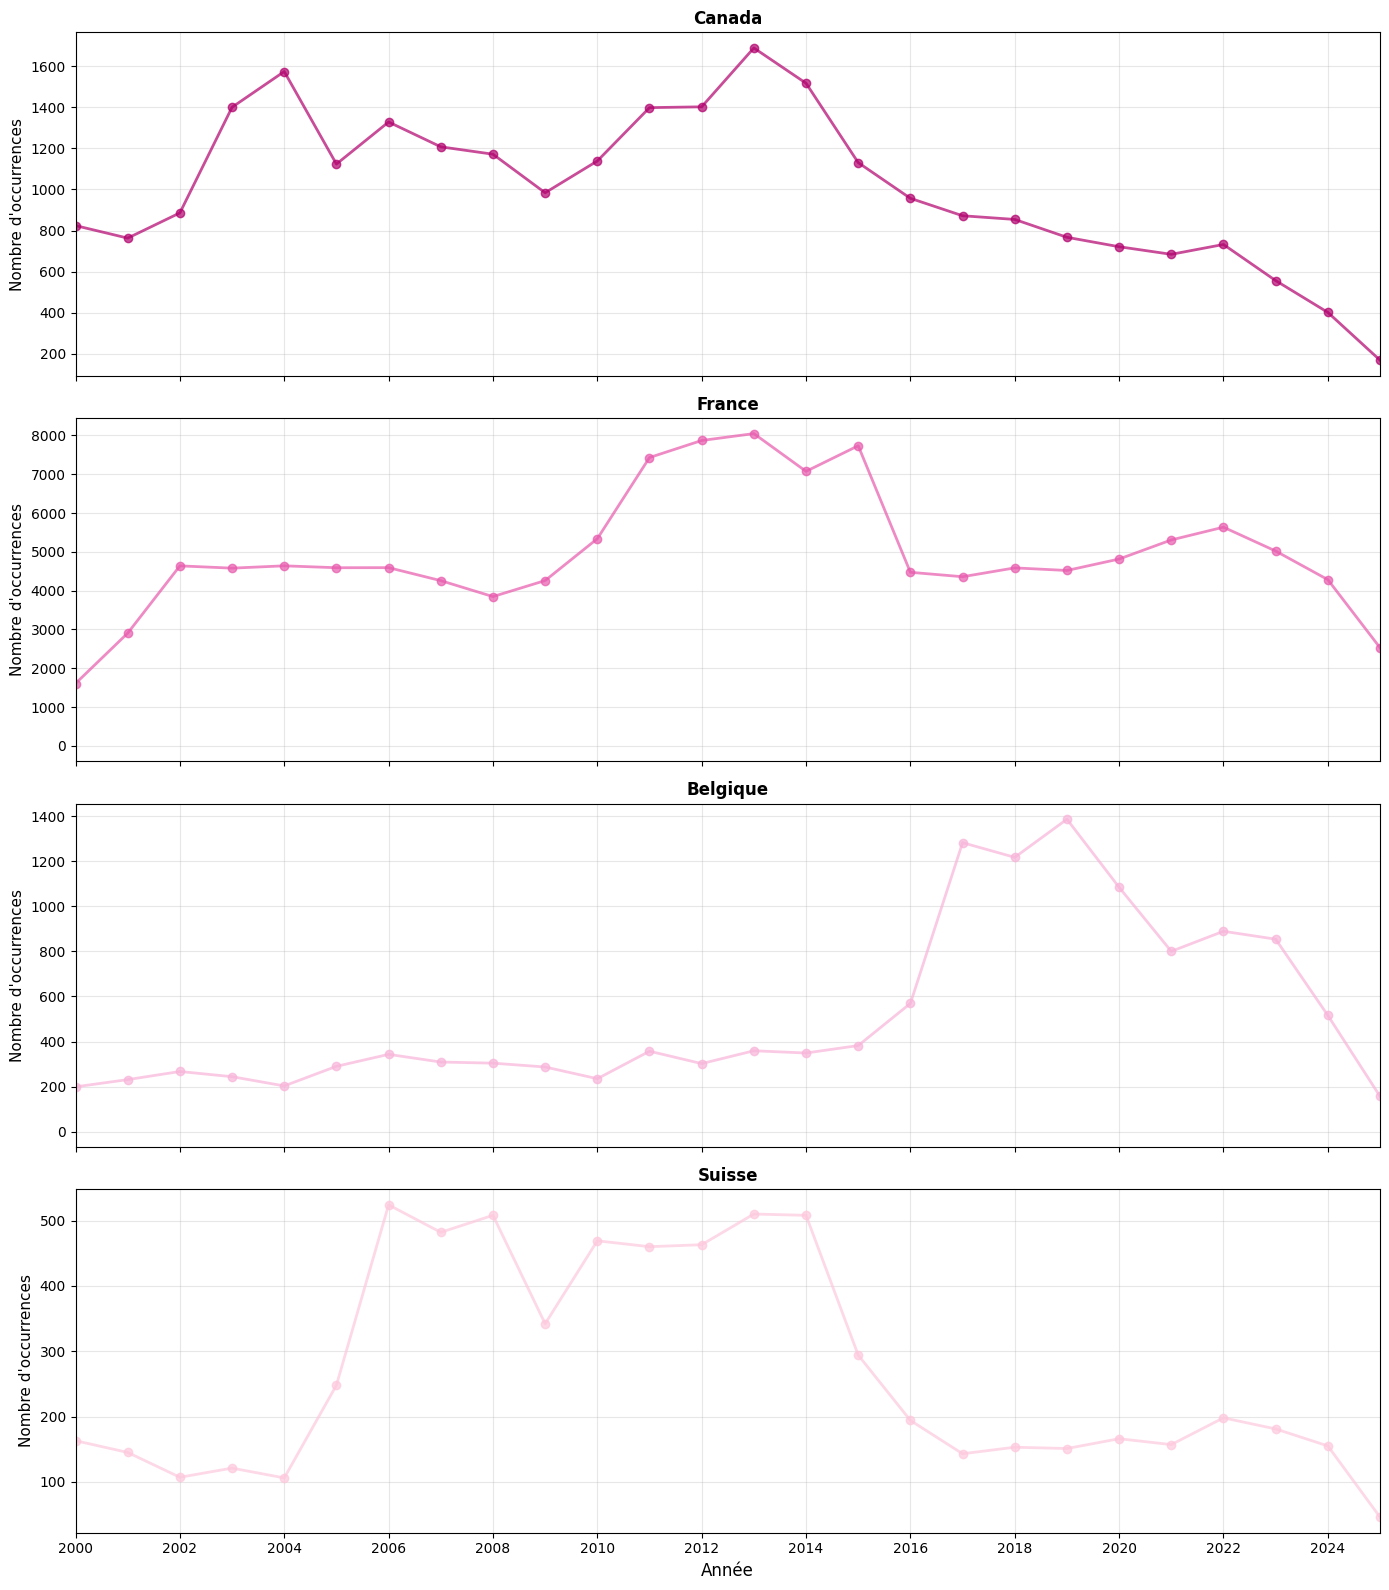

In [49]:


# Calculer les compteurs
canada = Counter(année_canada)
france = Counter(année_france)
belgique = Counter(année_belgique)
suisse = Counter(année_suisse)

# Créer 4 sous-graphiques empilés verticalement
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Fonction pour tracer un graphique
def plot_series(ax, annee_counts, title, color):
    sorted_annees = sorted(annee_counts.keys())
    counts = [annee_counts[a] for a in sorted_annees]
    ax.plot(sorted_annees, counts, linewidth=2, marker='o', markersize=6, 
            alpha=0.7, color=color)
    ax.set_xlim(2000, 2025)
    ax.set_xticks(range(2000, 2026, 2))
    ax.set_ylabel("Nombre d'occurrences", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Graphique 1
plot_series(axes[0], canada, 'Canada', '#B1006D')

# Graphique 2
plot_series(axes[1], france, 'France', '#E85AAD')

# Graphique 3
plot_series(axes[2], belgique, 'Belgique', '#F8B4D9')

# Graphique 4
plot_series(axes[3], suisse, 'Suisse', '#FDC8DD')

# Axe X commun (seulement le dernier graphique)
axes[3].set_xlabel('Année', fontsize=12)

plt.tight_layout()
plt.savefig('evolution_annees_4_graphiques.png', dpi=150, bbox_inches='tight')
plt.show()

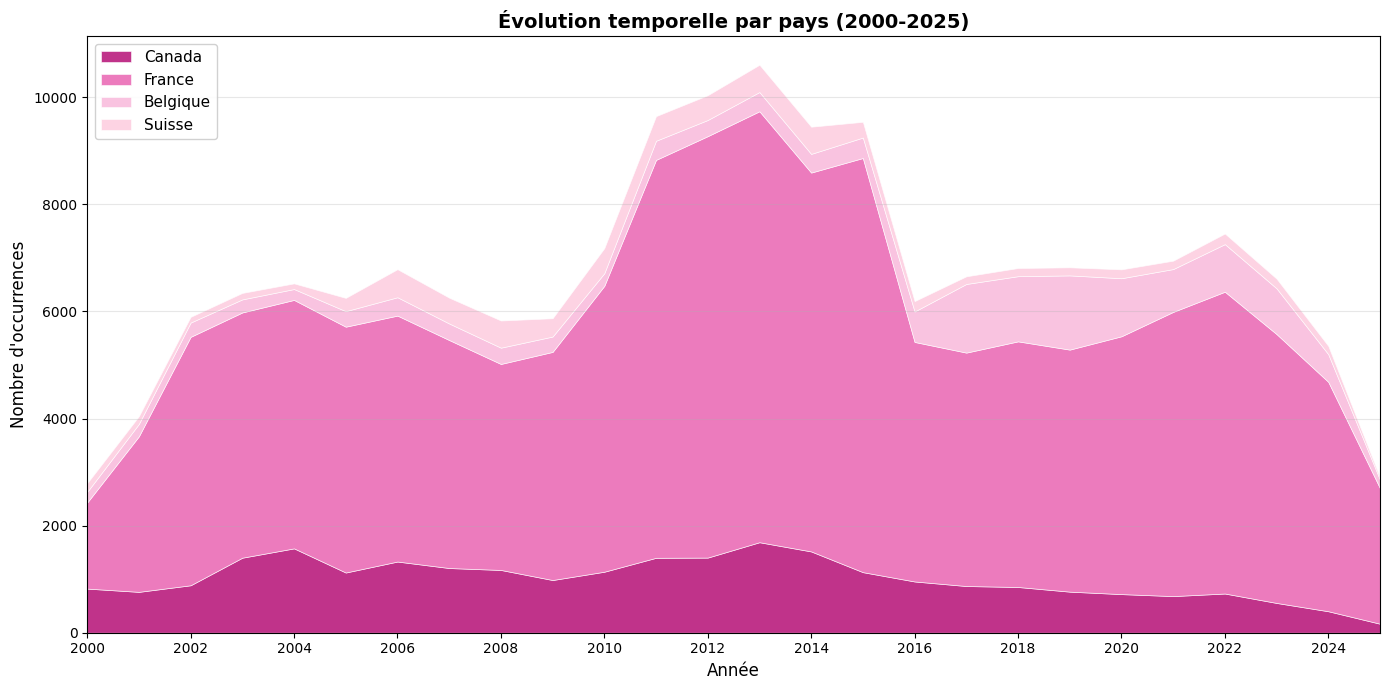

In [48]:
from collections import Counter
import matplotlib.pyplot as plt

# Calculer les compteurs
canada = Counter(année_canada)
france = Counter(année_france)
belgique = Counter(année_belgique)
suisse = Counter(année_suisse)

# Toutes les années de 2000 à 2025
all_years = list(range(2000, 2026))

# Créer les séries pour chaque pays (0 si l'année n'est pas présente)
canada_counts = [canada.get(y, 0) for y in all_years]
france_counts = [france.get(y, 0) for y in all_years]
belgique_counts = [belgique.get(y, 0) for y in all_years]
suisse_counts = [suisse.get(y, 0) for y in all_years]

# Créer le graphique
fig, ax = plt.subplots(figsize=(14, 7))

# Graphique empilé
ax.stackplot(all_years, canada_counts, france_counts, belgique_counts, suisse_counts,
             labels=['Canada', 'France', 'Belgique', 'Suisse'],
             colors=['#B1006D', '#E85AAD', '#F8B4D9', "#FDC8DD"],
             alpha=0.8, edgecolor='white', linewidth=0.5)

# Configuration
ax.set_xlim(2000, 2025)
ax.set_xticks(range(2000, 2026, 2))
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel("Nombre d'occurrences", fontsize=12)
ax.set_title('Évolution temporelle par pays (2000-2025)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('evolution_annees_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
année_canada = {}
année_france = {}
année_belgique = {}
année_suisse = {}
for pays, année, type in zip(df['pays'], df['année'], df['type']):
    if len(pays) > 0:
        for p in pays:
            if p == "Canada":
                année_canada[année] = année_canada.get(année, {})
                année_canada[année][type] = année_canada[année].get(type, 0) + 1

            elif p == "France":
                    année_france[année] = année_france.get(année, {})
                    année_france[année][type] = année_france[année].get(type, 0) + 1
            elif p == "Belgique":
                    année_belgique[année] = année_belgique.get(année, {})
                    année_belgique[année][type] = année_belgique[année].get(type, 0) + 1
            elif p == "Suisse":
                if type == "Fiction":
                    année_suisse[année] = année_suisse.get(année, {})
                    année_suisse[année][type] = année_suisse[année].get(type, 0) + 1
                elif type == "Réalité":
                    année_suisse[année] = année_suisse.get(année, {})
                    année_suisse[année][type] = année_suisse[année].get(type, 0) + 1

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Transformer le dictionnaire en DataFrame
df_canada = (
    pd.DataFrame.from_dict(année_canada, orient="index")
    .fillna(0)
    .rename_axis("année")
    .reset_index()
    .sort_values("année")
)

df_france = (
    pd.DataFrame.from_dict(année_france, orient="index")
    .fillna(0)
    .rename_axis("année")
    .reset_index()
    .sort_values("année")
)

df_belgique = (
    pd.DataFrame.from_dict(année_belgique, orient="index")
    .fillna(0)
    .rename_axis("année")
    .reset_index()
    .sort_values("année")
)

df_suisse = (
    pd.DataFrame.from_dict(année_suisse, orient="index")
    .fillna(0)
    .rename_axis("année")
    .reset_index()
    .sort_values("année")
)

In [56]:
donnees_pays = {
    "Canada": année_canada,
    "France": année_france,
    "Belgique": année_belgique,
    "Suisse": année_suisse,
}

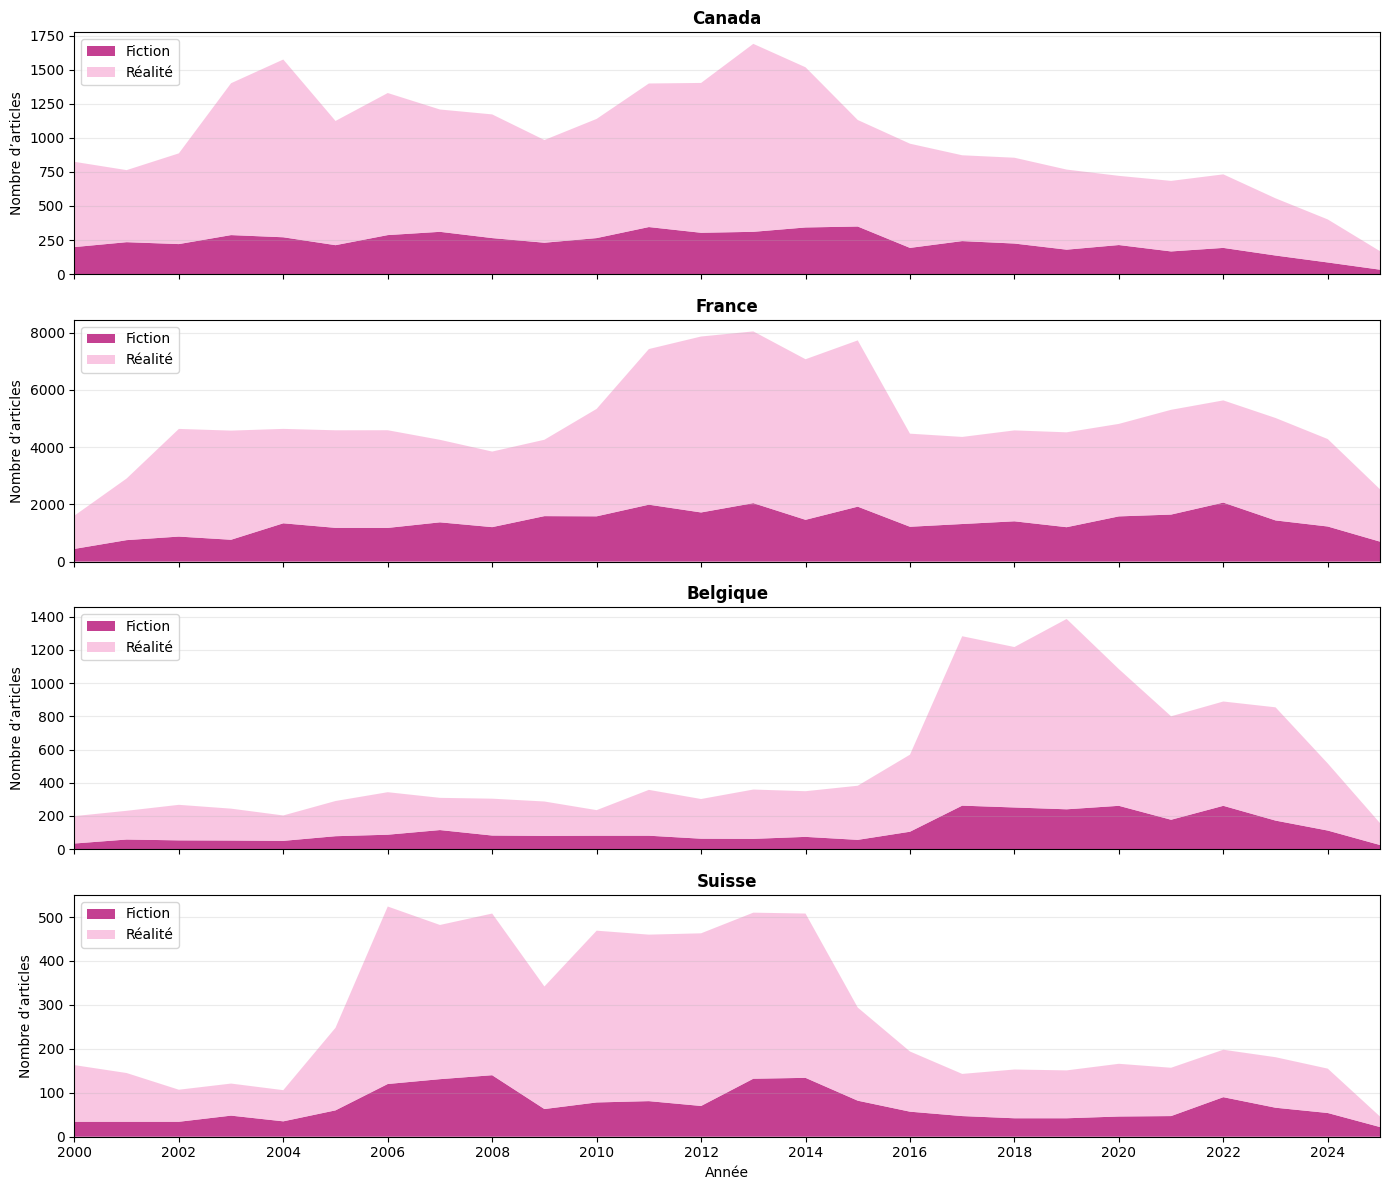

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=len(donnees_pays),
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

# Si un seul pays est fourni, axes n'est pas une liste
if len(donnees_pays) == 1:
    axes = [axes]

for ax, (pays, donnees) in zip(axes, donnees_pays.items()):

    tableau = (
        pd.DataFrame.from_dict(donnees, orient="index")
        .fillna(0)
        .rename_axis("année")
        .reset_index()
        .sort_values("année")
    )

    # S'assurer que les deux colonnes existent
    for colonne in ["Réalité", "Fiction"]:
        if colonne not in tableau.columns:
            tableau[colonne] = 0

    annees = tableau["année"].to_numpy()
    realite = tableau["Réalité"].to_numpy()
    fiction = tableau["Fiction"].to_numpy()

    ax.stackplot(
        annees,
        fiction,
        realite,
        labels=["Fiction", "Réalité"],
        colors=["#b1006d", "#f8b4d9"],
        alpha=0.75
    )

    ax.set_title(pays, fontweight="bold")
    ax.set_ylabel("Nombre d’articles")
    ax.grid(axis="y", alpha=0.25)
    ax.set_xlim(2000, 2025)

    # Éviter de répéter la légende inutilement
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Année")
ax.set_xticks(range(2000, 2026, 2))

plt.tight_layout()
plt.show()